# Lista 12d — GQA: InsectWingbeat Classification

Eksperymenty z Grouped Query Attention na danych szeregów czasowych InsectWingbeat (10 klas owadów).

Format danych: `X[i].shape = (200, n_channels)` gdzie n_channels ∈ {5, 7} — multivariate time series.
Projekcja wejściowa: `Linear(MAX_CHAN, d_model)` per timestep + CLS token.

**Eksperymenty:**
1. Siatka H×G (10 kombinacji × 3 seedy × 20 epok)

## 1. Importy i konfiguracja

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import time
import math
import random
import os
from collections import defaultdict, Counter
from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce GTX 1080
VRAM: 8.6 GB



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/mikol/ai_studies/Deep-Neural-Networks-PWR/.venv/lib/python3.11/site-pack

## 2. MLflow setup

In [2]:
import os
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('./mlruns')
mlflow.set_experiment('GQA_InsectWingbeat')
print('MLflow tracking URI: ./mlruns')
print('Experiment: GQA_InsectWingbeat')

MLflow tracking URI: ./mlruns
Experiment: GQA_InsectWingbeat


## 3. Dane — InsectWingbeat

In [3]:
X, y = load_classification("InsectWingbeat", extract_path="insect_data")
print(f'len(X): {len(X)}')
print(f'X[0].shape: {X[0].shape}')   # (seq_len, n_channels)
print(f'X[3].shape: {X[3].shape}')   # może mieć inną liczbę kanałów
print(f'Klasy: {set(y)}')

/tmp/ipykernel_6667/2673909869.py:1: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X, y = load_classification("InsectWingbeat", extract_path="insect_data")


len(X): 50000
X[0].shape: (200, 7)
X[3].shape: (200, 5)
Klasy: {np.str_('quinx_female'), np.str_('quinx_male'), np.str_('house_flies'), np.str_('fruit_flies'), np.str_('tarsalis_male'), np.str_('aedes_female'), np.str_('tarsalis_female'), np.str_('aedes_male'), np.str_('stigma_male'), np.str_('stigma_female')}


In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
NUM_CLASSES = len(le.classes_)
print(f'Klasy: {le.classes_}')
print(f'NUM_CLASSES: {NUM_CLASSES}')

SEQ_LEN  = X[0].shape[0]                                  # 200
MAX_CHAN  = max(X[i].shape[1] for i in range(len(X)))      # 7
print(f'SEQ_LEN: {SEQ_LEN}, MAX_CHAN: {MAX_CHAN}')

def to_tensor(xi):
    """(seq_len, n_chan) → (SEQ_LEN, MAX_CHAN) z zero-paddingiem kanałów jeśli n_chan < MAX_CHAN"""
    t = torch.tensor(xi, dtype=torch.float32)
    if t.shape[1] < MAX_CHAN:
        pad = torch.zeros(t.shape[0], MAX_CHAN - t.shape[1])
        t = torch.cat([t, pad], dim=1)
    return t  # [SEQ_LEN, MAX_CHAN]

sequences = [to_tensor(X[i]) for i in range(len(X))]
labels    = torch.tensor(y_encoded, dtype=torch.long)

print(f'sequences[0].shape: {sequences[0].shape}')
print(f'Rozkład klas: {dict(sorted(Counter(y_encoded.tolist()).items()))}')

Klasy: ['aedes_female' 'aedes_male' 'fruit_flies' 'house_flies' 'quinx_female'
 'quinx_male' 'stigma_female' 'stigma_male' 'tarsalis_female'
 'tarsalis_male']
NUM_CLASSES: 10
SEQ_LEN: 200, MAX_CHAN: 22
sequences[0].shape: torch.Size([200, 22])
Rozkład klas: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}


In [5]:
idx = list(range(len(sequences)))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42,
                                        stratify=y_encoded)
print(f'Train: {len(idx_train)}, Test: {len(idx_test)}')


class InsectDataset(Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        return sequences[idx], labels[idx]  # [SEQ_LEN, MAX_CHAN], scalar


def get_loaders(batch_size=64):
    train_loader = DataLoader(InsectDataset(idx_train), batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(InsectDataset(idx_test),  batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

_tl, _vl = get_loaders()
_x, _y = next(iter(_tl))
print(f'Batch: x={_x.shape}, y={_y.shape}')  # [B, 200, 7]

Train: 40000, Test: 10000
Batch: x=torch.Size([64, 200, 22]), y=torch.Size([64])


## 4. GQA — implementacja

In [ ]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_groups, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        assert num_groups <= num_heads and num_heads % num_groups == 0

        self.num_heads  = num_heads
        self.num_groups = num_groups
        self.d_k        = d_model // num_heads
        self.scale      = math.sqrt(self.d_k)
        hpg = num_heads // num_groups
        self.group_assignment = [i // hpg for i in range(num_heads)]

        self.W_Q = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_heads)])
        self.W_K = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        self.W_V = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        K_g = [self.W_K[g](x) for g in range(self.num_groups)]
        V_g = [self.W_V[g](x) for g in range(self.num_groups)]
        outputs = []
        for h in range(self.num_heads):
            g = self.group_assignment[h]
            scores = torch.bmm(self.W_Q[h](x), K_g[g].transpose(1, 2)) / self.scale
            attn = self.dropout(F.softmax(scores, dim=-1))
            outputs.append(torch.bmm(attn, V_g[g]))
        return self.W_O(torch.cat(outputs, dim=-1))


class GQAEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, num_groups, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.attn  = GroupedQueryAttention(d_model, num_heads, num_groups, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, dim_feedforward), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model), nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm1(x + self.drop(self.attn(x)))
        x = self.norm2(x + self.ffn(x))
        return x

_g = GroupedQueryAttention(64, 4, 2)
_o = _g(torch.randn(2, SEQ_LEN, 64))
assert _o.shape == (2, SEQ_LEN, 64)
print('GQA OK:', _o.shape)

GQA OK: torch.Size([2, 200, 64])


## 5. Model klasyfikacyjny

`Linear(MAX_CHAN, d_model)` jako projekcja wejściowa per timestep. CLS token prepended.

In [7]:
class InsectClassifier(nn.Module):
    def __init__(self, seq_len, in_channels, d_model=64, num_heads=8, num_groups=8,
                 num_layers=3, num_classes=10,
                 dim_feedforward=256, dropout=0.1, layer_configs=None):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)   # MAX_CHAN → d_model
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb    = nn.Embedding(seq_len + 1, d_model) # +1 dla CLS
        self.emb_drop   = nn.Dropout(dropout)

        if layer_configs is None:
            layer_configs = [{'num_groups': num_groups}] * num_layers

        self.layers = nn.ModuleList([
            GQAEncoderLayer(d_model, num_heads, cfg['num_groups'],
                            dim_feedforward, dropout)
            for cfg in layer_configs
        ])
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        # x: [B, SEQ_LEN, in_channels]
        B, L, _ = x.shape
        x   = self.input_proj(x)                         # [B, L, d_model]
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)                 # [B, L+1, d_model]
        pos = torch.arange(L + 1, device=x.device).unsqueeze(0)
        x   = self.emb_drop(x + self.pos_emb(pos))
        for layer in self.layers:
            x = layer(x)
        return self.classifier(x[:, 0, :])               # klasyfikacja na CLS

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


_m = InsectClassifier(seq_len=SEQ_LEN, in_channels=MAX_CHAN,
                      num_heads=4, num_groups=2, num_classes=NUM_CLASSES).to(DEVICE)
_o = _m(torch.randn(4, SEQ_LEN, MAX_CHAN).to(DEVICE))
print(f'Output: {_o.shape} | Params: {_m.count_params():,}')
del _m, _o

Output: torch.Size([4, 10]) | Params: 153,706


## 6. Pętla treningowa

In [8]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def measure_inference_time(model, loader, n_batches=50):
    model.eval()
    times = []
    for i, (x, _) in enumerate(loader):
        if i >= n_batches: break
        x = x.to(DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))


@torch.no_grad()
def measure_memory_mb(model, loader):
    if not torch.cuda.is_available(): return 0.0
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)
    torch.cuda.reset_peak_memory_stats()
    model(x)
    return torch.cuda.max_memory_allocated() / 1e6


def run_experiment(run_name, num_heads, num_groups, layer_configs=None,
                   seed=42, num_epochs=20, lr=3e-4, batch_size=64,
                   extra_params=None):
    mlflow.end_run()
    set_seed(seed)
    os.makedirs('models/insect', exist_ok=True)

    train_loader, test_loader = get_loaders(batch_size=batch_size)
    dataset_size = len(train_loader.dataset)

    if layer_configs is None:
        layer_configs = [{'num_groups': num_groups}] * 3

    gs = [cfg['num_groups'] for cfg in layer_configs]
    attn_type = 'MHA' if all(g == num_heads for g in gs) else ('MQA' if all(g == 1 for g in gs) else 'GQA')

    model = InsectClassifier(
        seq_len=SEQ_LEN, in_channels=MAX_CHAN,
        d_model=64, num_heads=num_heads,
        num_layers=3, num_classes=NUM_CLASSES,
        dim_feedforward=256, dropout=0.1,
        layer_configs=layer_configs
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()
    num_params = model.count_params()

    params = {
        'dataset': 'InsectWingbeat', 'num_heads': num_heads, 'num_groups': num_groups,
        'attention_type': attn_type, 'seed': seed, 'num_epochs': num_epochs,
        'lr': lr, 'batch_size': batch_size, 'seq_len': SEQ_LEN, 'in_channels': MAX_CHAN,
        'd_model': 64, 'num_params': num_params,
    }
    if extra_params:
        params.update(extra_params)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'epoch_time_s': []}
    best_test_acc = 0.0
    best_epoch    = 0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        train_start = time.perf_counter()
        pbar = tqdm(range(1, num_epochs + 1), desc=f'[{run_name}]')

        for epoch in pbar:
            t0 = time.perf_counter()
            t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion)
            v_loss, v_acc = evaluate(model, test_loader, criterion)
            scheduler.step()
            epoch_time = time.perf_counter() - t0

            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            history['test_loss'].append(v_loss)
            history['test_acc'].append(v_acc)
            history['epoch_time_s'].append(epoch_time)

            if v_acc > best_test_acc:
                best_test_acc = v_acc
                best_epoch    = epoch

            mlflow.log_metrics({
                'train_loss': t_loss, 'train_acc': t_acc,
                'test_loss':  v_loss, 'test_acc':  v_acc,
                'epoch_time_s': epoch_time,
            }, step=epoch)

            pbar.set_postfix(train=f'{t_acc:.4f}', test=f'{v_acc:.4f}')

        total_train_time  = time.perf_counter() - train_start
        final_test_acc    = history['test_acc'][-1]
        overfitting_gap   = history['train_acc'][-1] - final_test_acc
        avg_epoch_time    = float(np.mean(history['epoch_time_s']))
        tokens_per_second = (dataset_size * SEQ_LEN * num_epochs) / total_train_time

        inf_mean, inf_std = measure_inference_time(model, test_loader)
        memory_mb         = measure_memory_mb(model, test_loader)

        mlflow.log_metrics({
            'best_test_acc':      best_test_acc,
            'best_epoch':         best_epoch,
            'final_test_acc':     final_test_acc,
            'overfitting_gap':    overfitting_gap,
            'total_train_time_s': total_train_time,
            'avg_epoch_time_s':   avg_epoch_time,
            'tokens_per_second':  tokens_per_second,
            'inference_time_ms':  inf_mean,
            'inference_time_std': inf_std,
            'memory_mb':          memory_mb,
        })

        model_path = f'models/insect/{run_name}.pt'
        torch.save({
            'state_dict':    model.state_dict(),
            'num_heads':     num_heads,
            'num_groups':    num_groups,
            'layer_configs': layer_configs,
            'num_params':    num_params,
            'best_acc':      best_test_acc,
            'best_epoch':    best_epoch,
            'history':       history,
        }, model_path)
        mlflow.log_artifact(model_path)

        print(f'\n→ {run_name} | best={best_test_acc:.4f} (ep{best_epoch}) | '
              f'params={num_params:,} | {total_train_time/60:.1f}min | '
              f'inf={inf_mean:.1f}ms | mem={memory_mb:.0f}MB | '
              f'{tokens_per_second/1e6:.2f}M tok/s\n')

    return {
        'run_name':           run_name,
        'best_test_acc':      best_test_acc,
        'best_epoch':         best_epoch,
        'final_test_acc':     final_test_acc,
        'overfitting_gap':    overfitting_gap,
        'num_params':         num_params,
        'inference_time_ms':  inf_mean,
        'total_train_time_s': total_train_time,
        'avg_epoch_time_s':   avg_epoch_time,
        'tokens_per_second':  tokens_per_second,
        'memory_mb':          memory_mb,
        'history':            history,
    }

## 7. Sanity check — pojedynczy run

Zanim odpalisz sweep, sprawdź czy model w ogóle się uczy.

In [ ]:
# Pojedynczy test z większym modelem i wyższym lr
set_seed(42)
train_loader, test_loader = get_loaders(batch_size=64)

_model = InsectClassifier(
    seq_len=SEQ_LEN, in_channels=MAX_CHAN,
    d_model=128, num_heads=4, num_groups=4,
    num_layers=3, num_classes=NUM_CLASSES,
    dim_feedforward=512, dropout=0.1
).to(DEVICE)

_optimizer = torch.optim.Adam(_model.parameters(), lr=1e-3)
_criterion = nn.CrossEntropyLoss()
print(f'Params: {_model.count_params():,}')

for epoch in range(1, 31):
    t_loss, t_acc = train_epoch(_model, train_loader, _optimizer, _criterion)
    v_loss, v_acc = evaluate(_model, test_loader, _criterion)
    print(f'Epoch {epoch:2d} | train={t_acc:.4f} | test={v_acc:.4f}')

del _model, _optimizer

Params: 630,986
Epoch  1 | train=0.4209 | test=0.5583
Epoch  2 | train=0.5594 | test=0.5757
Epoch  3 | train=0.5857 | test=0.6015
Epoch  4 | train=0.6028 | test=0.6143
Epoch  5 | train=0.6114 | test=0.6156
Epoch  6 | train=0.6160 | test=0.6354
Epoch  7 | train=0.6198 | test=0.6257
Epoch  8 | train=0.6281 | test=0.6303
Epoch  9 | train=0.6304 | test=0.6319
Epoch 10 | train=0.6341 | test=0.6398
Epoch 11 | train=0.6370 | test=0.6336
Epoch 12 | train=0.6381 | test=0.6378
Epoch 13 | train=0.6433 | test=0.6502
Epoch 14 | train=0.6440 | test=0.6499
Epoch 15 | train=0.6479 | test=0.6533
Epoch 16 | train=0.6491 | test=0.6513
Epoch 17 | train=0.6529 | test=0.6552
Epoch 18 | train=0.6522 | test=0.6625
Epoch 19 | train=0.6555 | test=0.6486
Epoch 20 | train=0.6590 | test=0.6525
Epoch 21 | train=0.6583 | test=0.6637
Epoch 22 | train=0.6604 | test=0.6627
Epoch 23 | train=0.6607 | test=0.6641
Epoch 24 | train=0.6609 | test=0.6506
Epoch 25 | train=0.6627 | test=0.6636
Epoch 26 | train=0.6676 | test=0.6

## 8. Eksperyment 1 — Siatka H×G

Uruchom po sanity check — upewnij się że model się uczy.

In [ ]:
H_VALUES = [1, 2, 4, 8]
GRID = []
for H in H_VALUES:
    for G in [1, 2, 4, 8]:
        if G <= H and H % G == 0:
            GRID.append((H, G))

print(f'Kombinacji H×G: {len(GRID)}')
for H, G in GRID:
    label = 'MHA' if G == H else ('MQA' if G == 1 else 'GQA')
    print(f'  H={H}, G={G}  → {label}')

SEEDS = [42, 123, 777]

Kombinacji H×G: 10
  H=1, G=1  → MHA
  H=2, G=1  → MQA
  H=2, G=2  → MHA
  H=4, G=1  → MQA
  H=4, G=2  → GQA
  H=4, G=4  → MHA
  H=8, G=1  → MQA
  H=8, G=2  → GQA
  H=8, G=4  → GQA
  H=8, G=8  → MHA


In [ ]:
results_grid = defaultdict(list)

for H, G in GRID:
    label = 'MHA' if G == H else ('MQA' if G == 1 else f'GQA_G{G}')
    print(f'\n===== H={H}, G={G} ({label}) =====')
    for seed in SEEDS:
        result = run_experiment(
            run_name    = f'grid_H{H}_G{G}_seed{seed}',
            num_heads   = H,
            num_groups  = G,
            seed        = seed,
            num_epochs  = 20,
            extra_params= {'experiment': 'exp1_grid_HxG', 'H': H, 'G': G, 'label': label}
        )
        results_grid[(H, G)].append(result)

print('\n=== Siatka H×G zakończona ===')


===== H=1, G=1 (MHA) =====


[grid_H1_G1_seed42]: 100%|██████████| 20/20 [05:19<00:00, 15.99s/it, test=0.6503, train=0.6299]



→ grid_H1_G1_seed42 | best=0.6503 (ep20) | params=165,994 | 5.0min | inf=7.4ms | mem=71MB | 0.53M tok/s



[grid_H1_G1_seed123]: 100%|██████████| 20/20 [05:20<00:00, 16.01s/it, test=0.6298, train=0.6243]



→ grid_H1_G1_seed123 | best=0.6347 (ep17) | params=165,994 | 5.0min | inf=7.1ms | mem=71MB | 0.53M tok/s



...


→ grid_H8_G8_seed42 | best=0.6737 (ep19) | params=165,994 | 13.0min | inf=15.1ms | mem=86MB | 0.20M tok/s



[grid_H8_G8_seed123]: 100%|██████████| 20/20 [14:19<00:00, 42.99s/it, test=0.6655, train=0.6596]



→ grid_H8_G8_seed123 | best=0.6655 (ep20) | params=165,994 | 12.9min | inf=15.2ms | mem=86MB | 0.21M tok/s



[grid_H8_G8_seed777]: 100%|██████████| 20/20 [14:19<00:00, 42.95s/it, test=0.6721, train=0.6547]



→ grid_H8_G8_seed777 | best=0.6728 (ep19) | params=165,994 | 12.9min | inf=15.1ms | mem=86MB | 0.21M tok/s


=== Siatka H×G zakończona ===


## 9. Wizualizacje

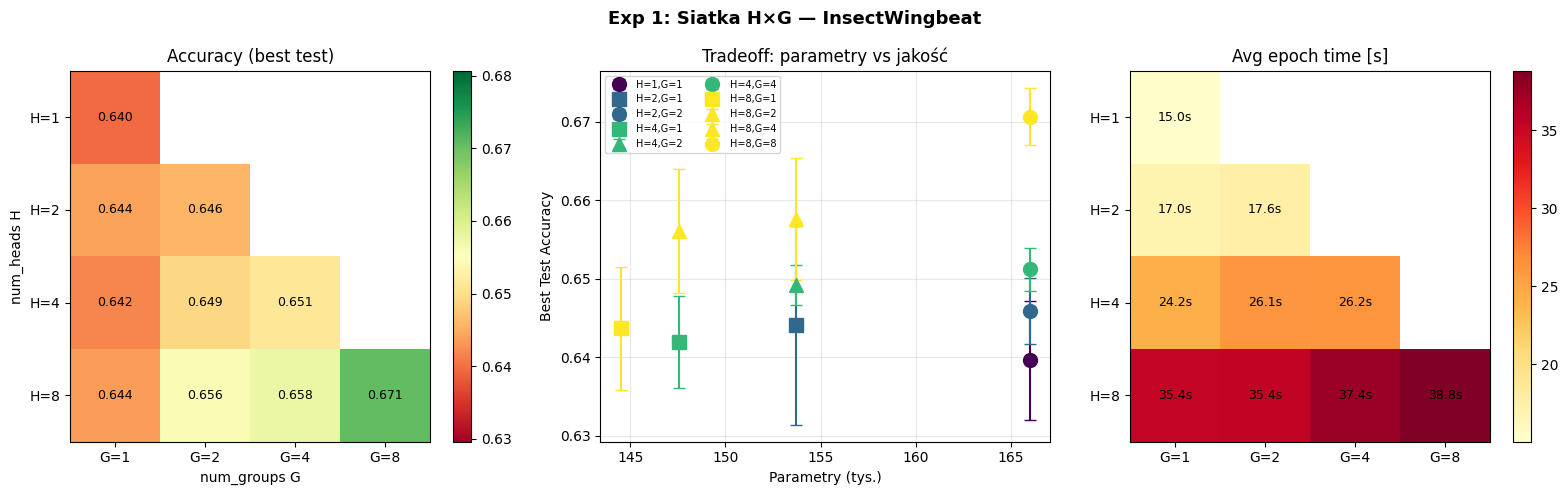

Wykres zapisany.


In [ ]:
H_list = sorted(set(H for H, G in GRID))
G_list = sorted(set(G for H, G in GRID))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# heatmapa accuracy
ax = axes[0]
matrix_acc = np.full((len(H_list), len(G_list)), np.nan)
for i, H in enumerate(H_list):
    for j, G in enumerate(G_list):
        if (H, G) in results_grid:
            matrix_acc[i, j] = np.mean([r['best_test_acc'] for r in results_grid[(H, G)]])

im = ax.imshow(matrix_acc, aspect='auto', cmap='RdYlGn',
               vmin=np.nanmin(matrix_acc)-0.01, vmax=np.nanmax(matrix_acc)+0.01)
ax.set_xticks(range(len(G_list))); ax.set_xticklabels([f'G={g}' for g in G_list])
ax.set_yticks(range(len(H_list))); ax.set_yticklabels([f'H={h}' for h in H_list])
ax.set_title('Accuracy (best test)')
ax.set_xlabel('num_groups G'); ax.set_ylabel('num_heads H')
plt.colorbar(im, ax=ax)
for i in range(len(H_list)):
    for j in range(len(G_list)):
        if not np.isnan(matrix_acc[i, j]):
            ax.text(j, i, f'{matrix_acc[i,j]:.3f}', ha='center', va='center', fontsize=9)

# params vs accuracy
ax = axes[1]
for H, G in GRID:
    rs     = results_grid[(H, G)]
    acc    = np.mean([r['best_test_acc'] for r in rs])
    std    = np.std([r['best_test_acc'] for r in rs])
    params = rs[0]['num_params'] / 1000
    color  = plt.cm.viridis(H_list.index(H) / max(1, len(H_list)-1))
    marker = 'o' if G == H else ('s' if G == 1 else '^')
    ax.errorbar(params, acc, yerr=std, fmt=marker, color=color, markersize=10,
                capsize=4, label=f'H={H},G={G}')
ax.set_xlabel('Parametry (tys.)'); ax.set_ylabel('Best Test Accuracy')
ax.set_title('Tradeoff: parametry vs jakość')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# avg epoch time heatmapa
ax = axes[2]
matrix_time = np.full((len(H_list), len(G_list)), np.nan)
for i, H in enumerate(H_list):
    for j, G in enumerate(G_list):
        if (H, G) in results_grid:
            matrix_time[i, j] = np.mean([r['avg_epoch_time_s'] for r in results_grid[(H, G)]])

im2 = ax.imshow(matrix_time, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(G_list))); ax.set_xticklabels([f'G={g}' for g in G_list])
ax.set_yticks(range(len(H_list))); ax.set_yticklabels([f'H={h}' for h in H_list])
ax.set_title('Avg epoch time [s]')
plt.colorbar(im2, ax=ax)
for i in range(len(H_list)):
    for j in range(len(G_list)):
        if not np.isnan(matrix_time[i, j]):
            ax.text(j, i, f'{matrix_time[i,j]:.1f}s', ha='center', va='center', fontsize=9)

plt.suptitle('Exp 1: Siatka H×G — InsectWingbeat', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_grid_insect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Wykres zapisany.')

## 10. Podsumowanie

In [ ]:
print('=== Podsumowanie — InsectWingbeat ===')
best_combo = max(GRID, key=lambda hg: np.mean([r['best_test_acc'] for r in results_grid[hg]]))
best_acc   = np.mean([r['best_test_acc'] for r in results_grid[best_combo]])
print(f'Najlepsza kombinacja: H={best_combo[0]}, G={best_combo[1]} → acc={best_acc:.4f}')

print(f'\n{"Wariant":18} {"Acc mean":10} {"Acc std":8} {"Params":12} {"Avg epoch":10} {"Mem MB"}')
print('-' * 72)
for H, G in GRID:
    label = 'MHA' if G==H else ('MQA' if G==1 else 'GQA')
    rs    = results_grid[(H, G)]
    accs  = [r['best_test_acc'] for r in rs]
    p     = rs[0]['num_params']
    ep_t  = np.mean([r['avg_epoch_time_s'] for r in rs])
    mem   = np.mean([r['memory_mb'] for r in rs])
    print(f'H={H} G={G} {label:8} {np.mean(accs):.4f}     {np.std(accs):.4f}   {p:10,}   {ep_t:.1f}s   {mem:.0f}MB')

print('\nZalogowane do ./mlruns, experiment GQA_InsectWingbeat')

=== Podsumowanie — InsectWingbeat ===
Najlepsza kombinacja: H=8, G=8 → acc=0.6707

Wariant            Acc mean   Acc std  Params       Avg epoch  Mem MB
------------------------------------------------------------------------
H=1 G=1 MHA      0.6396     0.0076      165,994   15.0s   71MB
H=2 G=1 MQA      0.6441     0.0127      153,706   17.0s   82MB
H=2 G=2 MHA      0.6458     0.0042      165,994   17.6s   85MB
H=4 G=1 MQA      0.6419     0.0058      147,562   24.2s   80MB
H=4 G=2 GQA      0.6492     0.0025      153,706   26.1s   82MB
H=4 G=4 MHA      0.6512     0.0027      165,994   26.2s   86MB
H=8 G=1 MQA      0.6437     0.0079      144,490   35.4s   80MB
H=8 G=2 GQA      0.6560     0.0079      147,562   35.4s   81MB
H=8 G=4 GQA      0.6576     0.0078      153,706   37.4s   82MB
H=8 G=8 MHA      0.6707     0.0037      165,994   38.8s   86MB

Zalogowane do ./mlruns, experiment GQA_InsectWingbeat


In [ ]:
class DynamicGroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_groups, dropout=0.1, ema_momentum=0.9):
        super().__init__()
        assert d_model % num_heads == 0
        assert num_groups <= num_heads and num_heads % num_groups == 0

        self.num_heads    = num_heads
        self.num_groups   = num_groups
        self.d_k          = d_model // num_heads
        self.scale        = math.sqrt(self.d_k)
        self.ema_momentum = ema_momentum

        self.W_Q = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_heads)])
        self.W_K = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        self.W_V = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer('k_norms', torch.ones(num_heads))
        hpg = num_heads // num_groups
        self.register_buffer('group_assignment',
                             torch.tensor([i // hpg for i in range(num_heads)], dtype=torch.long))

    def _update_assignment(self):
        order = torch.argsort(self.k_norms)
        hpg = self.num_heads // self.num_groups
        new_assignment = torch.zeros_like(self.group_assignment)
        for rank, head_idx in enumerate(order):
            new_assignment[head_idx] = rank // hpg
        self.group_assignment = new_assignment

    def forward(self, x):
        K_g = [self.W_K[g](x) for g in range(self.num_groups)]
        V_g = [self.W_V[g](x) for g in range(self.num_groups)]
        outputs = []
        for h in range(self.num_heads):
            g = self.group_assignment[h].item()
            scores = torch.bmm(self.W_Q[h](x), K_g[g].transpose(1, 2)) / self.scale
            attn = self.dropout(F.softmax(scores, dim=-1))
            outputs.append(torch.bmm(attn, V_g[g]))
        if self.training:
            with torch.no_grad():
                for h in range(self.num_heads):
                    g = self.group_assignment[h].item()
                    k_norm = K_g[g].norm(dim=-1).mean()
                    self.k_norms[h] = (self.ema_momentum * self.k_norms[h] +
                                       (1 - self.ema_momentum) * k_norm)
            self._update_assignment()
        return self.W_O(torch.cat(outputs, dim=-1))


class DynamicGQAEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, num_groups, dim_feedforward=256,
                 dropout=0.1, ema_momentum=0.9):
        super().__init__()
        self.attn  = DynamicGroupedQueryAttention(d_model, num_heads, num_groups,
                                                   dropout, ema_momentum)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, dim_feedforward), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model), nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm1(x + self.drop(self.attn(x)))
        x = self.norm2(x + self.ffn(x))
        return x


class DynamicInsectClassifier(nn.Module):
    def __init__(self, seq_len, in_channels, d_model=64, num_heads=8, num_groups=4,
                 num_layers=3, num_classes=10, dim_feedforward=256,
                 dropout=0.1, ema_momentum=0.9):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb    = nn.Embedding(seq_len + 1, d_model)
        self.emb_drop   = nn.Dropout(dropout)
        self.layers     = nn.ModuleList([
            DynamicGQAEncoderLayer(d_model, num_heads, num_groups,
                                   dim_feedforward, dropout, ema_momentum)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        B, L, _ = x.shape
        x   = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        pos = torch.arange(L + 1, device=x.device).unsqueeze(0)
        x   = self.emb_drop(x + self.pos_emb(pos))
        for layer in self.layers:
            x = layer(x)
        return self.classifier(x[:, 0, :])

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

    def get_assignments(self):
        return [layer.attn.group_assignment.tolist() for layer in self.layers]


# trening 
print('\n=== Exp 2: Naive GQA vs Dynamic GQA (H=8, G=4) ===')
print('Dla porównania używamy wyników grid[(8,4)] jako naive baseline\n')

results_dynamic = []
for seed in SEEDS:
    set_seed(seed)
    train_loader, test_loader = get_loaders(batch_size=64)

    model_dyn = DynamicInsectClassifier(
        seq_len=SEQ_LEN, in_channels=MAX_CHAN,
        d_model=64, num_heads=8, num_groups=4,
        num_layers=3, num_classes=NUM_CLASSES,
        dim_feedforward=256, dropout=0.1, ema_momentum=0.9
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model_dyn.parameters(), lr=3e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0

    mlflow.end_run()
    with mlflow.start_run(run_name=f'dynamic_H8_G4_seed{seed}'):
        mlflow.log_params({
            'dataset': 'InsectWingbeat', 'num_heads': 8, 'num_groups': 4,
            'attention_type': 'DynamicGQA', 'seed': seed, 'num_epochs': 20,
            'ema_momentum': 0.9, 'experiment': 'exp2_dynamic_gqa',
            'num_params': model_dyn.count_params(),
        })
        pbar = tqdm(range(1, 21), desc=f'[dynamic_seed{seed}]')
        for epoch in pbar:
            t_loss, t_acc = train_epoch(model_dyn, train_loader, optimizer, criterion)
            v_loss, v_acc = evaluate(model_dyn, test_loader, criterion)
            scheduler.step()
            if v_acc > best_acc:
                best_acc = v_acc
            mlflow.log_metrics({'train_acc': t_acc, 'test_acc': v_acc,
                                 'train_loss': t_loss, 'test_loss': v_loss}, step=epoch)
            pbar.set_postfix(train=f'{t_acc:.4f}', test=f'{v_acc:.4f}')

        mlflow.log_metric('best_test_acc', best_acc)
        final_assign = model_dyn.get_assignments()
        print(f'\n→ dynamic seed={seed} | best={best_acc:.4f} | '
              f'final assignments: {final_assign[0]}')

    results_dynamic.append(best_acc)

# podsumowanie
naive_accs = [r['best_test_acc'] for r in results_grid[(8, 4)]]
mha_accs   = [r['best_test_acc'] for r in results_grid[(8, 8)]]

print(f'\n=== Exp 2: Porównanie (H=8, G=4) ===')
print(f'{"Wariant":20} {"Acc mean":10} {"Acc std"}')
print('-' * 42)
print(f'{"MHA (G=8)":20} {np.mean(mha_accs):.4f}     {np.std(mha_accs):.4f}')
print(f'{"Naive GQA (G=4)":20} {np.mean(naive_accs):.4f}     {np.std(naive_accs):.4f}')
print(f'{"Dynamic GQA (G=4)":20} {np.mean(results_dynamic):.4f}     {np.std(results_dynamic):.4f}')


=== Exp 2: Naive GQA vs Dynamic GQA (H=8, G=4) ===
Dla porównania używamy wyników grid[(8,4)] jako naive baseline



[dynamic_seed42]: 100%|██████████| 20/20 [20:03<00:00, 60.16s/it, test=0.6430, train=0.6258]



→ dynamic seed=42 | best=0.6475 | final assignments: [3, 3, 0, 0, 2, 2, 1, 1]


[dynamic_seed123]: 100%|██████████| 20/20 [18:17<00:00, 54.88s/it, test=0.6329, train=0.6092]



→ dynamic seed=123 | best=0.6390 | final assignments: [1, 1, 2, 2, 3, 3, 0, 0]


[dynamic_seed777]: 100%|██████████| 20/20 [18:21<00:00, 55.08s/it, test=0.5996, train=0.5864]


→ dynamic seed=777 | best=0.6016 | final assignments: [2, 2, 3, 3, 1, 1, 0, 0]

=== Exp 2: Porównanie (H=8, G=4) ===
Wariant              Acc mean   Acc std
------------------------------------------
MHA (G=8)            0.6707     0.0037
Naive GQA (G=4)      0.6576     0.0078
Dynamic GQA (G=4)    0.6294     0.0199


=== Exp 3: Post-hoc grouping (H=8, G=4) ===
Trenowanie GQA baseline (naive, H=8, G=4)...


GQA pretrain: 100%|██████████| 20/20 [12:32<00:00, 37.62s/it]


GQA naive accuracy (po treningu): 0.6642
(dla porównania MHA z gridu: 0.6707)

Macierz podobieństwa W_Q (cosine similarity):
        H0   H1   H2   H3   H4   H5   H6   H7 
H0    1.00-0.03 0.10-0.15 0.07-0.19 0.06-0.20
H1   -0.03 1.00-0.12-0.13 0.02 0.08-0.06-0.08
H2    0.10-0.12 1.00 0.07 0.04 0.06 0.12-0.14
H3   -0.15-0.13 0.07 1.00-0.00 0.08-0.01 0.14
H4    0.07 0.02 0.04-0.00 1.00 0.04 0.08 0.01
H5   -0.19 0.08 0.06 0.08 0.04 1.00-0.11 0.00
H6    0.06-0.06 0.12-0.01 0.08-0.11 1.00-0.03
H7   -0.20-0.08-0.14 0.14 0.01 0.00-0.03 1.00

Stats (bez diagonali):
  min=-0.198, max=0.138, mean=-0.009, std=0.096

Assignmenty (H=8, G=4):
  naive       : [0, 0, 1, 1, 2, 2, 3, 3]  →  rozmiary grup: [2, 2, 2, 2]
  similarity  : [3, 2, 1, 0, 3, 2, 1, 0]  →  rozmiary grup: [2, 2, 2, 2]
  worst       : [0, 1, 3, 1, 3, 2, 2, 0]  →  rozmiary grup: [2, 2, 2, 2]
  random      : [3, 3, 1, 1, 1, 1, 1, 0]  →  rozmiary grup: [1, 5, 2]

Ewaluacja post-hoc (bez retreningu):
  naive       : 0.6642
  similarity 

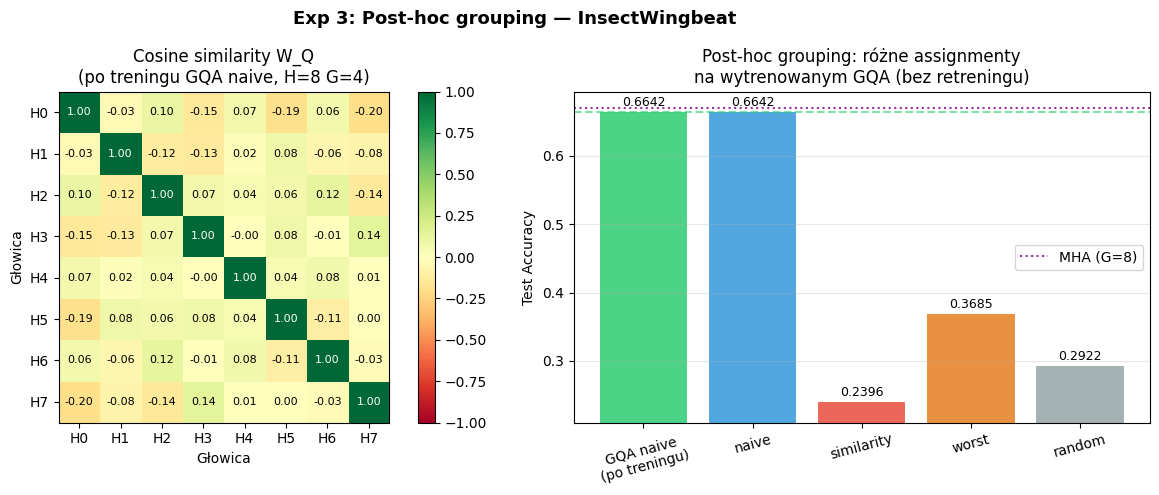


Najlepszy:  GQA naive
(po treningu) → 0.6642
Najgorszy:  similarity → 0.2396
Gap:        0.4246


In [ ]:
# ── Exp 3: Post-hoc grouping — zmiana assignmentu po treningu GQA ─────────
# Trenujemy GQA (H=8, G=4, naive), potem bez retreningu testujemy
# różne assignmenty głowic na tym samym modelu.

def compute_wq_similarity(model):
    W = torch.stack([layer.weight.data for layer in model.layers[0].attn.W_Q])
    W_flat = W.view(W.shape[0], -1).float()
    W_norm = F.normalize(W_flat, dim=1)
    sim = (W_norm @ W_norm.T).detach().cpu().float()
    return sim


def similarity_assignment_unequal(sim, num_groups):
    """Greedy clustering — pary najbardziej podobnych głowic razem. Grupy mogą być nierówne."""
    H = sim.shape[0]
    sim_work = sim.clone()
    sim_work.fill_diagonal_(-1)

    assigned  = [-1] * H
    group_id  = 0
    remaining = list(range(H))

    while group_id < num_groups - 1 and len(remaining) > (num_groups - group_id):
        best_i, best_j, best_s = -1, -1, -2.0
        for i in remaining:
            for j in remaining:
                if i != j and sim_work[i, j].item() > best_s:
                    best_s = sim_work[i, j].item()
                    best_i, best_j = i, j
        assigned[best_i] = group_id
        assigned[best_j] = group_id
        remaining.remove(best_i)
        remaining.remove(best_j)
        group_id += 1

    for idx in remaining:
        assigned[idx] = group_id
    return assigned


def evaluate_with_assignment(model, loader, assignment):
    """Podmienia group_assignment, ewaluuje, przywraca. Zero retreningu."""
    old_assignments = []
    for layer in model.layers:
        old_assignments.append(list(layer.attn.group_assignment))

    for layer in model.layers:
        layer.attn.group_assignment = list(assignment)

    criterion = nn.CrossEntropyLoss()
    _, acc = evaluate(model, loader, criterion)

    for layer, old in zip(model.layers, old_assignments):
        layer.attn.group_assignment = old
    return acc


# trenuj GQA (H=8, G=4, naive)
print('=== Exp 3: Post-hoc grouping (H=8, G=4) ===')
print('Trenowanie GQA baseline (naive, H=8, G=4)...')

set_seed(42)
train_loader, test_loader = get_loaders(batch_size=64)

base_model = InsectClassifier(
    seq_len=SEQ_LEN, in_channels=MAX_CHAN,
    d_model=64, num_heads=8, num_groups=4,
    num_layers=3, num_classes=NUM_CLASSES,
    dim_feedforward=256, dropout=0.1,
).to(DEVICE)

optimizer = torch.optim.Adam(base_model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

for epoch in tqdm(range(20), desc='GQA pretrain'):
    train_epoch(base_model, train_loader, optimizer, criterion)
    scheduler.step()

_, base_acc = evaluate(base_model, test_loader, criterion)
print(f'GQA naive accuracy (po treningu): {base_acc:.4f}')
print(f'(dla porównania MHA z gridu: {np.mean([r["best_test_acc"] for r in results_grid[(8,8)]]):.4f})')

# similarity matrix
sim = compute_wq_similarity(base_model)

print('\nMacierz podobieństwa W_Q (cosine similarity):')
header = '      ' + ''.join([f'  H{i} ' for i in range(8)])
print(header)
for i in range(8):
    row = f'H{i}   ' + ''.join([f'{sim[i,j].item():5.2f}' for j in range(8)])
    print(row)

mask     = ~torch.eye(8, dtype=torch.bool)
off_diag = sim[mask]
print(f'\nStats (bez diagonali):')
print(f'  min={off_diag.min().item():.3f}, max={off_diag.max().item():.3f}, '
      f'mean={off_diag.mean().item():.3f}, std={off_diag.std().item():.3f}')

# assignmenty — wszystkie w zakresie [0..3] 
naive_assign      = [0, 0, 1, 1, 2, 2, 3, 3]   # sąsiednie (jak było w treningu)
similarity_assign = similarity_assignment_unequal(sim, num_groups=4)
# worst: celowo łączy głowice które są do siebie niepodobne
# znajdź pary o najniższym podobieństwie
sim_work = sim.clone()
sim_work.fill_diagonal_(99)
worst_pairs = []
remaining_w = list(range(8))
for _ in range(4):
    if len(remaining_w) < 2:
        break
    min_val, min_i, min_j = 99.0, -1, -1
    for i in remaining_w:
        for j in remaining_w:
            if i != j and sim_work[i, j].item() < min_val:
                min_val = sim_work[i, j].item()
                min_i, min_j = i, j
    worst_pairs.append((min_i, min_j))
    remaining_w = [x for x in remaining_w if x not in (min_i, min_j)]

worst_assign = [0] * 8
for gid, (i, j) in enumerate(worst_pairs):
    worst_assign[i] = gid
    worst_assign[j] = gid

random.seed(99)
random_assign = [random.randint(0, 3) for _ in range(8)]

assignments = {
    'naive':      naive_assign,
    'similarity': similarity_assign,
    'worst':      worst_assign,
    'random':     random_assign,
}

print('\nAssignmenty (H=8, G=4):')
for name, a in assignments.items():
    groups = {g: [h for h, ga in enumerate(a) if ga == g] for g in sorted(set(a))}
    sizes  = [len(v) for v in groups.values()]
    print(f'  {name:12}: {a}  →  rozmiary grup: {sizes}')

# ── post-hoc ewaluacja ────────────────────────────────────────────────────
print('\nEwaluacja post-hoc (bez retreningu):')
results_posthoc = {'GQA naive\n(po treningu)': base_acc}
for name, assignment in assignments.items():
    acc = evaluate_with_assignment(base_model, test_loader, assignment)
    results_posthoc[name] = acc
    print(f'  {name:12}: {acc:.4f}')

# ── wizualizacja ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# heatmapa similarity
ax = axes[0]
sim_list = [[sim[i,j].item() for j in range(8)] for i in range(8)]
im = ax.imshow(sim_list, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('Cosine similarity W_Q\n(po treningu GQA naive, H=8 G=4)')
ax.set_xlabel('Głowica'); ax.set_ylabel('Głowica')
ax.set_xticks(range(8)); ax.set_yticks(range(8))
ax.set_xticklabels([f'H{i}' for i in range(8)])
ax.set_yticklabels([f'H{i}' for i in range(8)])
plt.colorbar(im, ax=ax)
for i in range(8):
    for j in range(8):
        val = sim[i,j].item()
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='black' if abs(val) < 0.7 else 'white')

# wykres accuracy
ax = axes[1]
names  = list(results_posthoc.keys())
accs   = list(results_posthoc.values())
colors = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22', '#95a5a6']
bars   = ax.bar(names, accs, color=colors[:len(names)], alpha=0.85)
ax.axhline(base_acc, color='#2ecc71', linestyle='--', linewidth=1.5, alpha=0.6)
ax.axhline(np.mean([r['best_test_acc'] for r in results_grid[(8,8)]]),
           color='purple', linestyle=':', linewidth=1.5, alpha=0.8, label='MHA (G=8)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Post-hoc grouping: różne assignmenty\nna wytrenowanym GQA (bez retreningu)')
ax.set_ylim(min(accs) - 0.03, max(accs) + 0.03)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Exp 3: Post-hoc grouping — InsectWingbeat', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp3_posthoc_insect.png', dpi=150, bbox_inches='tight')
plt.show()

# ── podsumowanie ──────────────────────────────────────────────────────────
best  = max(results_posthoc, key=results_posthoc.get)
worst = min(results_posthoc, key=results_posthoc.get)
print(f'\nNajlepszy:  {best} → {results_posthoc[best]:.4f}')
print(f'Najgorszy:  {worst} → {results_posthoc[worst]:.4f}')
print(f'Gap:        {results_posthoc[best] - results_posthoc[worst]:.4f}')

### Eksperyment layer config

In [9]:
LAYER_CONFIGS = {
    'All_MHA':    [8, 8, 8],
    'First_GQA':  [2, 8, 8],
    'Mid_GQA':    [8, 2, 8],
    'Last_GQA':   [8, 8, 2],
    'First2_GQA': [2, 2, 8],
    'Last2_GQA':  [8, 2, 2],
    'All_GQA':    [2, 2, 2],
}
SEEDS = [42, 123, 777]

for cfg_name, G_per_layer in LAYER_CONFIGS.items():
    for seed in SEEDS:
        layer_configs = [{'num_groups': G} for G in G_per_layer]
        run_experiment(
            run_name      = f'lw_{cfg_name}_seed{seed}',
            num_heads     = 8, num_groups = 2,
            layer_configs = layer_configs,
            seed          = seed, num_epochs = 20,
            extra_params  = {
                'experiment': 'exp_layer_wise',
                'config': cfg_name,
                'G_layer1': G_per_layer[0],
                'G_layer2': G_per_layer[1],
                'G_layer3': G_per_layer[2],
            }
        )


[lw_All_MHA_seed42]: 100%|██████████| 20/20 [14:55<00:00, 44.78s/it, test=0.6732, train=0.6647]



→ lw_All_MHA_seed42 | best=0.6737 (ep19) | params=165,994 | 13.9min | inf=15.8ms | mem=76MB | 0.19M tok/s



[lw_All_MHA_seed123]: 100%|██████████| 20/20 [14:34<00:00, 43.75s/it, test=0.6655, train=0.6596]



→ lw_All_MHA_seed123 | best=0.6655 (ep20) | params=165,994 | 13.3min | inf=15.7ms | mem=76MB | 0.20M tok/s



[lw_All_MHA_seed777]: 100%|██████████| 20/20 [14:35<00:00, 43.78s/it, test=0.6721, train=0.6547]


...


→ lw_All_GQA_seed42 | best=0.6451 (ep18) | params=147,562 | 12.9min | inf=16.6ms | mem=71MB | 0.21M tok/s



[lw_All_GQA_seed123]: 100%|██████████| 20/20 [13:26<00:00, 40.33s/it, test=0.6635, train=0.6390]



→ lw_All_GQA_seed123 | best=0.6635 (ep18) | params=147,562 | 13.3min | inf=17.7ms | mem=71MB | 0.20M tok/s



[lw_All_GQA_seed777]: 100%|██████████| 20/20 [14:09<00:00, 42.50s/it, test=0.6568, train=0.6372]



→ lw_All_GQA_seed777 | best=0.6595 (ep19) | params=147,562 | 14.0min | inf=17.1ms | mem=71MB | 0.19M tok/s

